<a href="https://colab.research.google.com/github/wide-bridge/AIFFEL_quest_eng/blob/main/M1_Grad_CAM_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 M1. Grad-CAM 개념과 구현 (2H)

**한국AX산업협회 의료 AI 개발 실무 교육과정 — Day 6**

| 항목 | 내용 |
|------|------|
| 목표 | Grad-CAM 직접 구현 + torchcam 비교 + 임상 해석 |
| 환경 | Google Colab (T4 GPU) |
| 입력 | Day 5 산출물 `day5_resnet50_best.pt`, `day5_model.py` |
| 데이터 | Day 4·5 ChestX-ray test split |
| 시간 | 2시간 |

---

## 0. 환경 설정

In [1]:
# ============================================================
# 📦 패키지 설치
# ============================================================
# Google Colab에서 실행하세요.
# GPU 설정: Runtime > Change runtime type > T4 GPU

!pip install -q torch torchvision matplotlib numpy pillow opencv-python
!pip install -q torchcam  # Grad-CAM 라이브러리
!pip install medmnist

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >=

In [2]:
# ──────────────────────────────────────────────────────────
# 디바이스 설정 (Colab GPU / Apple Silicon MPS / CPU 자동 감지)
# 이 셀에서 정의한 DEVICE를 노트북 전체에서 사용합니다.
# ──────────────────────────────────────────────────────────
import torch

def get_device():
    """Colab(CUDA) → Mac(MPS) → CPU 순으로 사용 가능한 디바이스를 반환"""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

DEVICE = get_device()
print(f"사용 디바이스: {DEVICE}")

사용 디바이스: cuda


✅ 폰트 설정: picked='NanumGothic'  family=['sans-serif']  sans-serif[0]='NanumGothic'


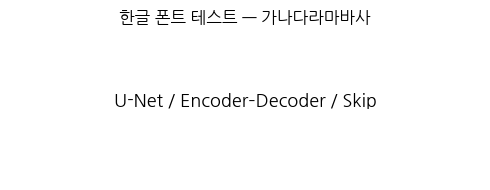

In [3]:
# 한글 폰트 자동 설정 — cross-platform (macOS / Colab / Windows / Linux)
import subprocess, os, glob, platform
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def setup_korean_font():
    # 1) Colab → NanumGothic 설치 보장
    try:
        import google.colab  # noqa: F401
        is_colab = True
    except ImportError:
        is_colab = False

    if is_colab:
        FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        if not os.path.exists(FONT_PATH):
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"],
                           check=True, capture_output=False)
        for f in glob.glob(os.path.join(mpl.get_cachedir(), "*.json")):
            os.remove(f)
        if os.path.exists(FONT_PATH):
            fm.fontManager.addfont(FONT_PATH)

    # 2) 우선순위 리스트 — 가장 먼저 발견되는 것을 사용
    candidates = ['NanumGothic', 'AppleGothic', 'Apple SD Gothic Neo',
                  'Malgun Gothic', 'Noto Sans CJK KR']
    available_names = {f.name for f in fm.fontManager.ttflist}
    picked = next((c for c in candidates if c in available_names), None)

    if picked:
        # font.family를 'sans-serif'로 두고, sans-serif 리스트 맨 앞에 한글 폰트 prepend
        # → matplotlib이 글리프 찾을 때 자동 fallback 가능
        current = list(plt.rcParams.get('font.sans-serif', []))
        plt.rcParams['font.sans-serif'] = [picked] + [x for x in current if x != picked]
        plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False

    # 캐시 무효화 (font.family 변경 즉시 반영)
    try:
        fm._get_font.cache_clear()
    except Exception:
        pass

    print(f"✅ 폰트 설정: picked={picked!r}  family={plt.rcParams['font.family']}  "
          f"sans-serif[0]={plt.rcParams['font.sans-serif'][0]!r}")

    fig, ax = plt.subplots(figsize=(5, 2))
    ax.set_title("한글 폰트 테스트 — 가나다라마바사")
    ax.text(0.5, 0.5, "U-Net / Encoder–Decoder / Skip", ha="center", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

setup_korean_font()


In [4]:
# 체크포인트 환경 설정 (Colab → Drive mount / 로컬 그대로)
# Day 5 산출물 day5_resnet50_best.pt를 로드하기 위한 사전 설정.
# Colab이면 Google Drive를 mount해서 Drive 안의 체크포인트에 접근.
#/content/drive/MyDrive/의료AI/checkpoints/day5_resnet50_best.pt

def setup_ckpt_env():
    is_colab = False
    try:
        import google.colab
        is_colab = True
    except ImportError:
        pass

    import os
    if is_colab:
        from google.colab import drive
        drive.mount('/content/drive')
        ckpt_dir = '/content/drive/MyDrive/의료AI/checkpoints'
    else:
        ckpt_dir = os.path.join(os.getcwd(), 'checkpoints')
    print(f"✅ 체크포인트 디렉토리: {ckpt_dir}")
    return ckpt_dir

CKPT_DIR = setup_ckpt_env()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 체크포인트 디렉토리: /content/drive/MyDrive/의료AI/checkpoints


In [5]:
def build_resnet50_for_pneumonia(num_classes=2):
    import torch.nn as nn
    import torchvision.models as models

    model = models.resnet50(weights=None)
    model.conv1 = nn.Conv2d(
        1, 64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

---
## 📖 Part 1 — 왜 Grad-CAM인가

### 의료 AI의 블랙박스 문제
- Day 5에서 ResNet50으로 폐렴/정상 분류는 됐다. 그러나 **"왜 그렇게 판단했나"** 는 모름
- 영상의학과 보조, SaMD 규제, 오분류 분석 모두 **해석가능성(interpretability)** 을 요구

### Grad-CAM 한 줄 정의
> **마지막 conv feature map** `A^k` **에 대한 class score** `y^c` **의 gradient를 채널별 평균(α_k) → A^k 가중합 → ReLU**

### Gradient 기반 XAI 비교 — "분모만 바꿔도 의미가 달라진다"

| 용도 | 분자 | 분모 | 결과 |
|------|------|------|------|
| Backprop 학습 | Loss `L` | Weights `W` | 가중치 업데이트 |
| Saliency Map (Simonyan 2014) | `y^c` | input pixel `x_ij` | 픽셀 단위, noisy |
| **Grad-CAM** (Selvaraju 2017) | `y^c` | feature map `A^k_ij` | coarse, 의미 단위 |

### CAM → Grad-CAM
- **CAM** (Zhou et al., CVPR 2016): GAP 구조 필수 — 강한 제약
- **Grad-CAM** (Selvaraju et al., ICCV 2017): gradient로 일반화, 아키텍처 무관

> **핵심**: 학습된 모델을 그대로 두고 **hook만 붙여서** 해석 가능.

---
## 🎯 실습 1 — Grad-CAM 직접 구현 [강사 시연]

**목표**: PyTorch hook으로 feature map과 gradient를 직접 캡처해 Grad-CAM heatmap 생성

**사용 라이브러리**: `torch`, `torch.nn.functional`, `torchvision`, `matplotlib`

| 단계 | 내용 |
|------|------|
| 1-1 | 문제 정의 — 입력 X → 모델 출력 y_c를 만든 픽셀이 어디인지 |
| 1-2 | Day 5 산출물 (`day5_resnet50_best.pt`) 로드 |
| 1-3 | 대상 layer 식별 (`model.layer4[-1]`) |
| 1-4 | Forward hook 등록 — feature map 캡처 |
| 1-5 | Backward hook 등록 — gradient 캡처 |
| 1-6 | 순전파 + 타겟 클래스 역전파 |
| 1-7 | Grad-CAM 계산 (α_k 가중합 → ReLU) |
| 1-8 | 입력 크기로 upsample + overlay 시각화 |

### 1-1. 문제 정의

```
  입력 X (224×224×3)            출력 y_c (폐렴 확률)
      │                              ▲
      ▼                              │
  [ ResNet50 ] ──── layer4 feature map A^k (7×7×2048)
                       │
                       └── "이 7×7 격자 중 어디가 y_c를 만들었나?"
```

> 가중치는 학습 안 함 (추론만). hook으로 중간 텐서를 들여다본다.

In [6]:
import traceback

CKPT_PATH = os.path.join(CKPT_DIR, 'day5_resnet50_best.pt')
print(f"CKPT_PATH: {CKPT_PATH} — exists? {os.path.exists(CKPT_PATH)}")

model = build_resnet50_for_pneumonia(num_classes=2)

try:
    state = torch.load(CKPT_PATH, map_location="cpu")

    print(type(state))
    if isinstance(state, dict):
        print("checkpoint keys:", state.keys())

        for k in ("model_state_dict", "state_dict"):
            if k in state:
                state = state[k]
                print(f"✅ state dict key 사용: {k}")
                break

    model.load_state_dict(state, strict=True)
    print(f"✅ Day 5 체크포인트 로드 성공: {CKPT_PATH}")

except Exception as e:
    print("⚠️ Day 5 체크포인트 로드 실패")
    print("에러 타입:", type(e))
    print("에러 내용:", repr(e))
    traceback.print_exc()

model = model.to(DEVICE).eval()
print(f"모델 디바이스: {next(model.parameters()).device}")

CKPT_PATH: /content/drive/MyDrive/의료AI/checkpoints/day5_resnet50_best.pt — exists? True
<class 'dict'>
checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_acc'])
✅ state dict key 사용: model_state_dict
✅ Day 5 체크포인트 로드 성공: /content/drive/MyDrive/의료AI/checkpoints/day5_resnet50_best.pt
모델 디바이스: cuda:0


In [7]:
# ============================================================
# 실습 1-2: Day 5 산출물 로드
# ============================================================
# Day 5에서 학습한 `day5_resnet50_best.pt`를 위에서 설정한 CKPT_DIR에서 로드.
# 파일이 없으면 ImageNet pretrained로 대체.

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms

CKPT_PATH = os.path.join(CKPT_DIR, 'day5_resnet50_best.pt')
print(f"CKPT_PATH: {CKPT_PATH} — exists? {os.path.exists(CKPT_PATH)}")

def build_resnet50_for_pneumonia(num_classes=2):
    """Day 5와 동일한 head 구조 (FC만 교체된 ResNet50)"""
    model = models.resnet50(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_resnet50_for_pneumonia(num_classes=2)

try:
    state = torch.load(CKPT_PATH, map_location=DEVICE)
    if isinstance(state, dict):
        for k in ('model_state_dict', 'state_dict'):
            if k in state:
                state = state[k]
                break
    model.load_state_dict(state)
    print(f"✅ Day 5 체크포인트 로드 성공: {CKPT_PATH}")
except Exception as e:
    print(f"⚠️ Day 5 체크포인트 로드 실패 ({e}). ImageNet pretrained로 대체합니다.")
    model = models.resnet50(weights='IMAGENET1K_V2')
    model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(DEVICE).eval()
print(f"모델 디바이스: {next(model.parameters()).device}")

CKPT_PATH: /content/drive/MyDrive/의료AI/checkpoints/day5_resnet50_best.pt — exists? True
✅ Day 5 체크포인트 로드 성공: /content/drive/MyDrive/의료AI/checkpoints/day5_resnet50_best.pt
모델 디바이스: cuda:0


In [8]:
print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
for name, module in model.named_children():
    print(name, type(module).__name__)

conv1 Conv2d
bn1 BatchNorm2d
relu ReLU
maxpool MaxPool2d
layer1 Sequential
layer2 Sequential
layer3 Sequential
layer4 Sequential
avgpool AdaptiveAvgPool2d
fc Linear


In [24]:
# ============================================================
# 실습 1-3: 대상 layer 식별
# ============================================================
# ResNet50의 마지막 conv block 출력은 model.layer4[-1] (Bottleneck)
# 이 블록의 forward output이 (B, 2048, 7, 7) feature map

target_layer = model.layer4[-1]
print(f"대상 layer: {target_layer.__class__.__name__}")
print(f"layer4 자식: {[type(m).__name__ for m in model.layer4]}")

대상 layer: Bottleneck
layer4 자식: ['Bottleneck', 'Bottleneck', 'Bottleneck']


In [25]:
# ============================================================
# 실습 1-4 ~ 1-7: Grad-CAM 클래스 정의 (forward/backward hook + 가중합)
# ============================================================
import torch.nn.functional as F

class GradCAM:
    """직접 구현 Grad-CAM — Selvaraju et al., 2017"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.features = None    # forward에서 캡처
        self.gradients = None   # backward에서 캡처
        # ── Forward hook 등록 ────────────────────────────────
        # "target_layer가 forward를 끝낼 때마다 _save_features를 호출해줘"
        # 라고 PyTorch에 사전 예약. self.model(x) 호출 시 PyTorch 내부의
        # nn.Module.__call__ 이 forward 직후 등록된 hook들을 자동 실행.
        # 콜백 시그니처: fn(module, inp, out) — out이 우리가 원하는 A^k.
        # 반환된 핸들(fwd_handle)은 나중에 .remove()로 해제 (메모리 누수 방지).
        self.fwd_handle = target_layer.register_forward_hook(self._save_features)

        # ── Backward hook 등록 ───────────────────────────────
        # "이 layer로 gradient가 역전파될 때마다 _save_gradients를 호출해줘"
        # score.backward() 호출 시 PyTorch가 자동 발동.
        # 콜백 시그니처: fn(module, grad_in, grad_out) — grad_out[0]이 ∂y^c/∂A^k.
        # full_ 버전은 PyTorch 1.8+ 표준 (구버전 register_backward_hook는
        # 다중 입력 layer에서 grad가 부정확하게 전달되는 버그가 있었음).
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_features(self, module, inp, out):
        self.features = out.detach()  # (B, C, H, W)

    def _save_gradients(self, module, grad_in, grad_out):
        # grad_out은 tuple — 첫 번째 텐서가 dL/d(feature map)
        self.gradients = grad_out[0].detach()

    def __call__(self, input_tensor, target_class=None):
        """입력 1장 → Grad-CAM heatmap (H, W).

        흐름: forward → backward → α_k 계산 → 가중합 → ReLU → 정규화
        공식: L_Grad-CAM^c = ReLU( Σ_k α_k^c · A^k ),  α_k^c = mean_{i,j}(∂y^c/∂A^k_ij)

        주의: 특정 layer/입력 조합에서 Σ α_k·A_k가 전 공간에 걸쳐 음수가 되면
        ReLU가 전부 0으로 죽여 heatmap이 단일 색(파란색)으로 보입니다.
        이 경우 |pre-ReLU| 로 fallback해 신호의 분포는 볼 수 있게 합니다.
        """
        # ── ① gradient 초기화 ─────────────────────────────────
        # 이전 호출에서 남은 .grad가 누적되면 heatmap이 오염되므로 매번 비움
        self.model.zero_grad()

        # ── ② Forward — feature map 캡처 ──────────────────────
        # forward 통과 시 _save_features가 자동 발동 → self.features에 A^k 저장
        # ResNet50 layer4 출력 기준: self.features = (1, 2048, 7, 7)
        logits = self.model(input_tensor)  # (1, num_classes)

        # ── ③ Target class 결정 ───────────────────────────────
        # 명시 안 하면 모델이 가장 높게 예측한 클래스를 자동 선택
        # 의도적으로 다른 클래스의 heatmap을 보려면 target_class=0 등으로 지정
        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        # ── ④ Backward — y^c 의 gradient 캡처 ─────────────────
        # logits[:, target_class] = y^c (타겟 클래스 점수)
        # .sum()은 batch=1을 스칼라로 만들기 위함 (backward는 스칼라에서만 시작 가능)
        # backward 호출 시 _save_gradients가 자동 발동 → self.gradients에 ∂y^c/∂A^k 저장
        score = logits[:, target_class].sum()
        score.backward()

        # ── ⑤ α_k 계산 (gradient의 공간 평균) ─────────────────
        # 공식: α_k^c = (1/Z) Σ_i Σ_j (∂y^c / ∂A^k_ij)
        # 의미: "k번째 채널이 평균적으로 y^c를 얼마나 밀어올렸나" = 채널별 중요도
        # (1, 2048, 7, 7) → 공간(H, W) 평균 → (1, 2048, 1, 1)
        # keepdim=True로 차원 유지 → 다음 줄에서 A^k와 브로드캐스팅 가능
        alpha = self.gradients.mean(dim=(2, 3), keepdim=True)

        # ── ⑥ 가중합 — α_k 로 채널 합치기 ──────────────────────
        # alpha (1, 2048, 1, 1) × features (1, 2048, 7, 7) → 브로드캐스트 곱
        # 채널 차원(dim=1)으로 sum → 2048개 채널이 1장의 7×7 맵으로 합쳐짐
        # 결과: 공간상 각 위치가 y^c에 얼마나 기여했는지 (음수 가능)
        cam_raw = (alpha * self.features).sum(dim=1, keepdim=True)  # (1, 1, 7, 7)

        # ── ⑦ ReLU — 양의 기여만 살리기 ────────────────────────
        # y^c를 "올린" 픽셀만 보고 싶음. 음수는 오히려 점수를 깎은 영역이라
        # "어디를 보고 폐렴이라 했나"라는 질문에는 잡음
        cam = F.relu(cam_raw)

        # ── ⑧ Fallback — 전부 음수일 때 구제 (디버깅용) ────────
        # 드물게 모든 위치가 음수 → ReLU 후 전부 0 → heatmap이 단색(파랑)으로 죽음
        # 예: 폐렴(1)을 봤는데 모델은 정상(0)을 강하게 예측한 영상
        # 이때는 |pre-ReLU|로 신호의 방향성은 잃지만 분포는 보이게 함
        if cam.amax() < 1e-8:
            cam = cam_raw.abs()
            print(f"  ⚠️ Grad-CAM: ReLU 후 신호가 0 → |pre-ReLU|로 fallback "
                  f"(이 layer의 모든 채널 가중치가 음의 기여를 했음)")

        # ── ⑨ Min-max 정규화 — [0, 1] 스케일 ──────────────────
        # raw 값은 영상마다 스케일이 천차만별 → 시각화/오버레이용으로 [0, 1] 정규화
        # jet colormap의 표준 입력 범위가 [0, 1]
        # + 1e-8 은 전부 0일 때 0/0 division 방지 (수치 안정성)
        cam_min, cam_max = cam.amin(dim=(2,3), keepdim=True), cam.amax(dim=(2,3), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        # ── ⑩ 반환 — matplotlib이 쓸 수 있는 numpy 배열로 ─────
        # .squeeze(): (1, 1, 7, 7) → (7, 7)
        # target_class: None 입력 시 실제 어느 클래스를 봤는지 알 수 있게 같이 반환
        # logits: 후처리(확률 변환 등)에 사용. .detach()로 graph에서 떼어 메모리 누수 방지
        return cam.squeeze().cpu().numpy(), target_class, logits.detach().cpu()

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

print("GradCAM 클래스 정의 완료")


GradCAM 클래스 정의 완료


In [26]:
# ============================================================
# 실습 1-8: 입력 영상 준비 + Grad-CAM 적용 + overlay 시각화
# ============================================================
# Day 5와 동일한 데이터(MedMNIST ChestMNIST test split, 1ch, /255 정규화)를 사용.
# 모델 conv1이 1채널이므로 grayscale 그대로 입력해야 한다.
import numpy as np
from medmnist import ChestMNIST

test_ds = ChestMNIST(split='test', download=True, size=64)

def prep_input_from_idx(idx, target_size=224):
    """test_ds의 idx 샘플 → (input_tensor[1,1,H,W], display_img[H,W], label)"""
    pil, lbl = test_ds[idx]
    arr = np.array(pil, dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    t = torch.from_numpy(arr / 255.0).float().unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=(target_size, target_size), mode='bilinear', align_corners=False)
    label = int(np.array(lbl).sum() > 0)  # multi-label sum>0 → 폐 질환 있음(1)
    return t.to(DEVICE), t[0, 0].cpu().numpy(), label

# 라벨 있는(=질환) 첫 샘플 1장으로 데모
sample_idx = next(i for i in range(len(test_ds)) if np.array(test_ds[i][1]).sum() > 0)
input_tensor, img_resized, demo_label = prep_input_from_idx(sample_idx)
print(f"✅ ChestMNIST 테스트 샘플 #{sample_idx} 로드 (label={demo_label}), tensor={tuple(input_tensor.shape)}")

# Grad-CAM 실행
gradcam = GradCAM(model, target_layer)
cam_np, pred_cls, logits = gradcam(input_tensor, target_class=None)
print(f"예측 클래스: {pred_cls}, logits: {logits.numpy()}")
print(f"CAM shape: {cam_np.shape} (예상: 7×7)")

✅ ChestMNIST 테스트 샘플 #2 로드 (label=1), tensor=(1, 1, 224, 224)
예측 클래스: 0, logits: [[ 0.16508673 -0.09490514]]
CAM shape: (7, 7) (예상: 7×7)


✅ ChestMNIST 테스트 샘플 #2 로드 (label=1), tensor=(1, 1, 224, 224)
예측 클래스: 0, logits: [[ 0.16508673 -0.09490514]]
CAM shape (interpolate 전): (7, 7) ← layer4 feature map과 같은 7×7


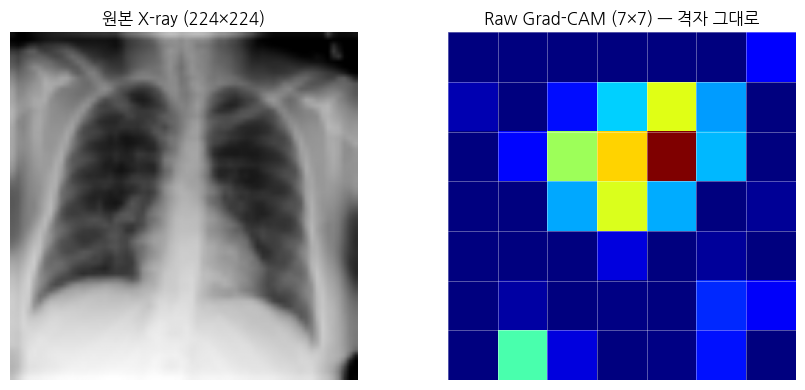

⚠️ 7×7 격자가 그대로 보임 → 224×224 영상과 픽셀 단위로 겹치려면 upsample 필요


In [28]:
# ============================================================
# 실습 1-8 (A): 입력 영상 준비 + Grad-CAM 적용 + Raw heatmap(7×7) 확인
# ============================================================
# Day 5와 동일한 데이터(MedMNIST ChestMNIST test split, 1ch, /255 정규화)를 사용.
# 모델 conv1이 1채널이므로 grayscale 그대로 입력해야 한다.
import numpy as np
from medmnist import ChestMNIST

test_ds = ChestMNIST(split='test', download=True, size=64)

def prep_input_from_idx(idx, target_size=224):
    """test_ds의 idx 샘플 → (input_tensor[1,1,H,W], display_img[H,W], label)"""
    pil, lbl = test_ds[idx]
    arr = np.array(pil, dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    t = torch.from_numpy(arr / 255.0).float().unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=(target_size, target_size), mode='bilinear', align_corners=False)
    label = int(np.array(lbl).sum() > 0)  # multi-label sum>0 → 폐 질환 있음(1)
    return t.to(DEVICE), t[0, 0].cpu().numpy(), label

# 라벨 있는(=질환) 첫 샘플 1장으로 데모
sample_idx = next(i for i in range(len(test_ds)) if np.array(test_ds[i][1]).sum() > 0)
input_tensor, img_resized, demo_label = prep_input_from_idx(sample_idx)
print(f"✅ ChestMNIST 테스트 샘플 #{sample_idx} 로드 (label={demo_label}), tensor={tuple(input_tensor.shape)}")

# Grad-CAM 실행
gradcam = GradCAM(model, target_layer)
cam_np, pred_cls, logits = gradcam(input_tensor, target_class=None)
print(f"예측 클래스: {pred_cls}, logits: {logits.numpy()}")
print(f"CAM shape (interpolate 전): {cam_np.shape} ← layer4 feature map과 같은 7×7")

# ── Raw 7×7 heatmap 시각화 (interpolate 전) ─────────────────
# 원본 영상은 224×224인데 Grad-CAM은 7×7 → 해상도 불일치 시각적 확인
# interpolation='nearest'로 7×7 격자를 그대로 보여줌 (matplotlib이 자동 보간하지 않게)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img_resized, cmap='gray')
axes[0].set_title('원본 X-ray (224×224)'); axes[0].axis('off')
axes[1].imshow(cam_np, cmap='jet', interpolation='nearest')
axes[1].set_title('Raw Grad-CAM (7×7) — 격자 그대로')
axes[1].axis('off')
# 7×7 격자 경계선
for i in range(8):
    axes[1].axhline(i - 0.5, color='white', lw=0.4, alpha=0.6)
    axes[1].axvline(i - 0.5, color='white', lw=0.4, alpha=0.6)
plt.tight_layout(); plt.show()
print("⚠️ 7×7 격자가 그대로 보임 → 224×224 영상과 픽셀 단위로 겹치려면 upsample 필요")

upsampled CAM shape: (224, 224) ← 영상과 같은 크기 → overlay 가능


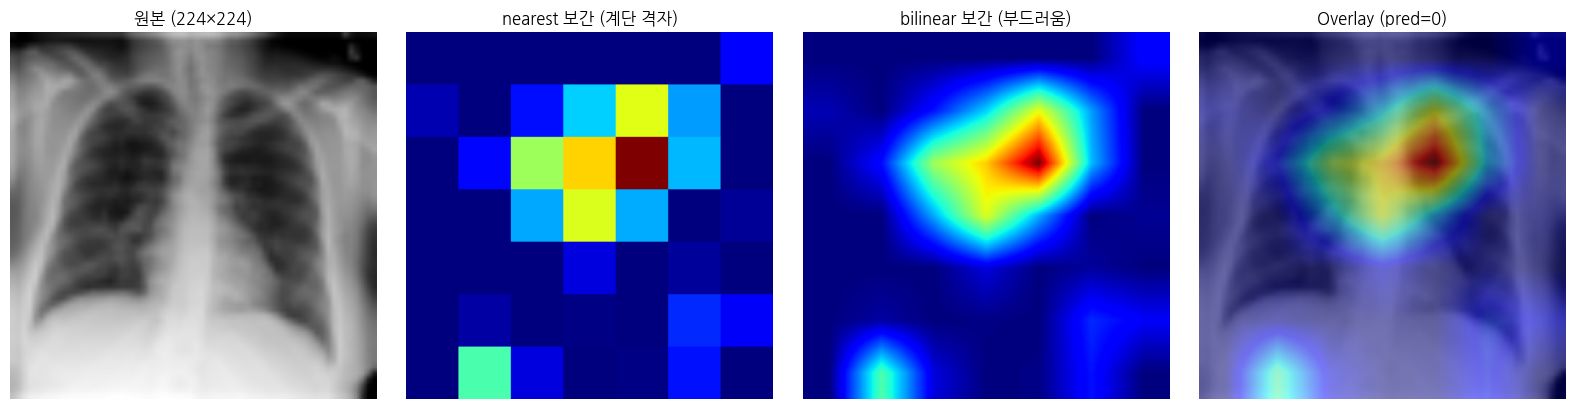

✅ bilinear가 격자 경계를 부드럽게 만들어 overlay에 적합
   (nearest는 7×7 격자가 그대로 보여 임상 해석에 부적합)


In [29]:
# ============================================================
# 실습 1-8 (B): bilinear upsample (7×7 → 224×224) + overlay 시각화
# ============================================================
# 7×7 raw heatmap을 입력 영상과 같은 224×224로 키워야 overlay 가능.
# 보간 방식(nearest vs bilinear)이 시각적으로 어떻게 다른지 함께 비교.

# (1) bilinear 보간 — Grad-CAM 표준. 4-이웃 가중평균으로 부드러운 그라데이션
cam_upsampled = F.interpolate(
    torch.from_numpy(cam_np)[None, None],   # (7,7) → (1,1,7,7) — F.interpolate는 4D 필요
    size=(224, 224),                         # 목표 해상도: 원본 영상과 동일
    mode='bilinear',                         # 부드러운 보간 (논문 표준)
    align_corners=False                      # OpenCV/PIL과 일치하는 표준 모드
).squeeze().numpy()

# (2) nearest 보간 — 비교용. 가장 가까운 픽셀 값 복사 → 계단 모양 유지
cam_nearest = F.interpolate(
    torch.from_numpy(cam_np)[None, None],
    size=(224, 224), mode='nearest'
).squeeze().numpy()

print(f"upsampled CAM shape: {cam_upsampled.shape} ← 영상과 같은 크기 → overlay 가능")

# ── 4패널 비교: 원본 / nearest / bilinear / overlay ─────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_resized, cmap='gray'); axes[0].set_title('원본 (224×224)'); axes[0].axis('off')
axes[1].imshow(cam_nearest, cmap='jet'); axes[1].set_title('nearest 보간 (계단 격자)'); axes[1].axis('off')
axes[2].imshow(cam_upsampled, cmap='jet'); axes[2].set_title('bilinear 보간 (부드러움)'); axes[2].axis('off')
axes[3].imshow(img_resized, cmap='gray')
axes[3].imshow(cam_upsampled, cmap='jet', alpha=0.5) # 알파를 조절하면 투명도가 조정됨
axes[3].set_title(f'Overlay (pred={pred_cls})'); axes[3].axis('off')
plt.tight_layout(); plt.show()

gradcam.remove_hooks()  # hook 해제 — 메모리 누수 방지
print("✅ bilinear가 격자 경계를 부드럽게 만들어 overlay에 적합")
print("   (nearest는 7×7 격자가 그대로 보여 임상 해석에 부적합)")

### 💡 해석

- **빨간 영역** = 모델이 예측 클래스 score를 높이는 데 강하게 기여한 영역
- 폐렴 사례라면 폐 실질(중하부) 부근에 attention이 모이는 게 "그럴듯한" 시그널
- 만약 attention이 영상 가장자리·텍스트·기기 마크에 있다면 → shortcut learning 의심 (M2에서 다룬다)

> **핵심**: Grad-CAM은 "모델이 본 곳"을 보여주지만, **그것이 임상적으로 옳은지는 별도 검증 필요**.

---
## ✏️ 실습 1-B — Grad-CAM 적용 실험 [수강생 실습]

| 과제 | 변경 포인트 | 확인할 것 |
|------|-----------|---------|
| ① 본인 선택 영상 | test set에서 3장 선택해 overlay 생성 | 폐렴 사례에서 attention이 흉부 내부에 위치하는가 |
| ② 대상 layer 변경 | `layer4` ↔ `layer3` ↔ `layer2` 비교 | 얕은 layer는 더 좁고 디테일, 깊은 layer는 더 넓고 의미적 |
| ③ (도전) 클래스 비교 | 같은 영상에서 정상(0) vs 폐렴(1) Grad-CAM 비교 | 클래스별 attention이 다른 영역을 가리키는지 |

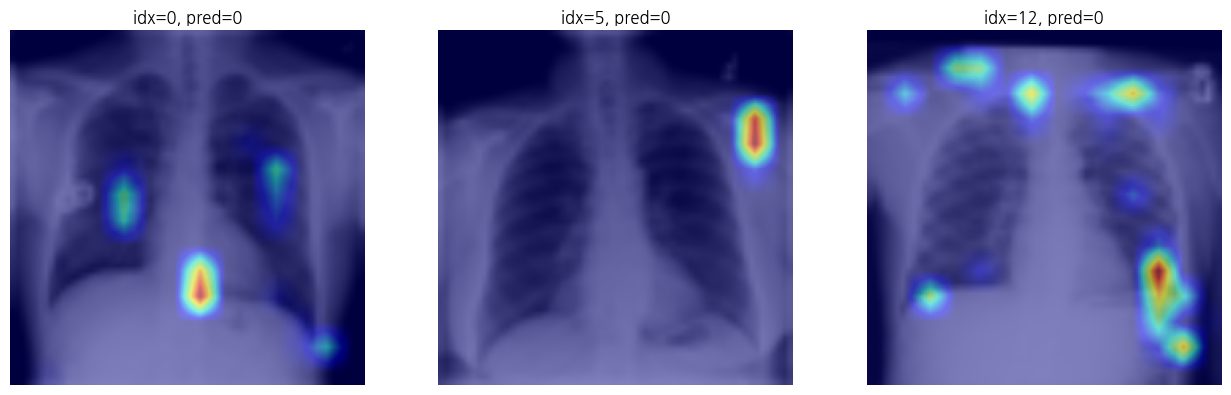

In [30]:
# ============================================================
# ✏️ 과제 ①: 본인이 고른 target layer + 영상 3장에 Grad-CAM 적용
# ============================================================

# 비교할 영상 인덱스 (자유롭게 변경 가능)
my_indices = [0, 5, 12]

# TODO: GradCAM의 두 번째 인자(target_layer)를 직접 채우세요.
#       Grad-CAM은 "어떤 layer의 feature map에 hook을 걸지"를 명시해야 동작합니다.
#   ▸ ResNet50의 마지막 conv block: model.layer4[-1]   ← 가장 의미적, 7×7 해상도
#   ▸ 중간 layer:                    model.layer3[-1]   ← 14×14, 의미와 해상도의 균형
#   ▸ 얕은 layer:                    model.layer2[-1]   ← 28×28, 디테일↑ 의미↓
gradcam_demo = GradCAM(model, model.layer3[-1])  # ← TODO: 여기를 채우세요

# ----- 아래 코드는 수정하지 마세요 -----
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, idx in enumerate(my_indices):
    t_i, img_i, _ = prep_input_from_idx(idx)
    cam_i, cls_i, _ = gradcam_demo(t_i, target_class=None)
    cam_up = F.interpolate(torch.from_numpy(cam_i)[None, None], size=(224, 224),
                            mode='bilinear', align_corners=False).squeeze().numpy()
    axes[i].imshow(img_i, cmap='gray'); axes[i].imshow(cam_up, cmap='jet', alpha=0.5)
    axes[i].set_title(f'idx={idx}, pred={cls_i}'); axes[i].axis('off')
plt.tight_layout(); plt.show()
gradcam_demo.remove_hooks()

  ⚠️ Grad-CAM: ReLU 후 신호가 0 → |pre-ReLU|로 fallback (이 layer의 모든 채널 가중치가 음의 기여를 했음)


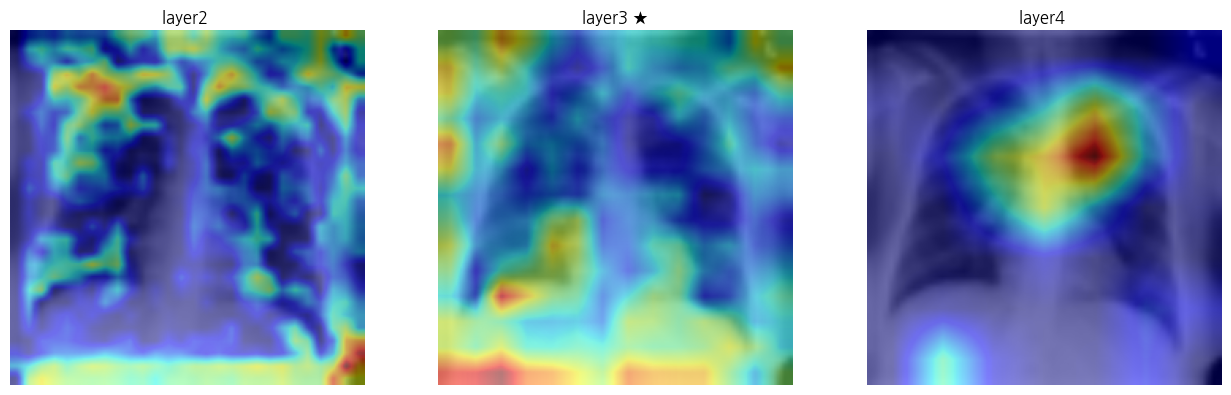

In [31]:
# ============================================================
# ✏️ 과제 ②: 대상 layer를 바꿔서 Grad-CAM 비교
# ============================================================
# TODO 2: layer 이름을 바꿔서 결과를 비교하세요
my_layer_name = 'layer3'  # TODO: 'layer2' / 'layer3' / 'layer4' 중 선택

# ----- 아래 코드는 수정하지 마세요 -----
layer_dict = {'layer2': model.layer2[-1], 'layer3': model.layer3[-1], 'layer4': model.layer4[-1]}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, name in enumerate(['layer2', 'layer3', 'layer4']):
    gc = GradCAM(model, layer_dict[name])
    cam_l, _, _ = gc(input_tensor, target_class=None)
    cam_up = F.interpolate(torch.from_numpy(cam_l)[None, None], size=(224, 224),
                            mode='bilinear', align_corners=False).squeeze().numpy()
    is_selected = (name == my_layer_name)
    axes[i].imshow(img_resized, cmap='gray'); axes[i].imshow(cam_up, cmap='jet', alpha=0.5)
    title = f'{name} {"★" if is_selected else ""}'
    axes[i].set_title(title); axes[i].axis('off')
    gc.remove_hooks()
plt.tight_layout(); plt.show()


📋 sample_idx=2  |  실제 라벨: 폐렴(1)  |  모델 예측: 정상(0)  |  ❌ 오분류


/tmp/ipykernel_12936/2506467494.py:29: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


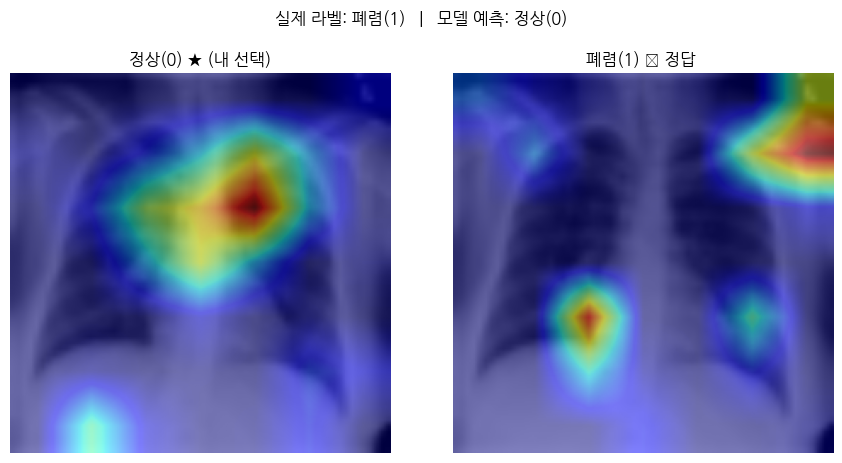

In [32]:
# ============================================================
# ⭐ 도전 과제 ③: 같은 영상에 대해 target_class를 바꿔보기
# ============================================================
# TODO 3: target_class를 바꿔서 한 영상에서 두 클래스의 Grad-CAM 차이 확인
my_target_class = 0  # TODO: 0(정상) 또는 1(폐렴) 중 선택

# ----- 아래 코드는 수정하지 마세요 -----
# 실제 라벨과 모델 예측을 함께 출력 (정/오분류 여부를 한눈에)
true_label_name = '정상(0)' if demo_label == 0 else '폐렴(1)'
pred_label_name = '정상(0)' if pred_cls == 0 else '폐렴(1)'
match_mark = '✅ 정분류' if pred_cls == demo_label else '❌ 오분류'
print(f"📋 sample_idx={sample_idx}  |  실제 라벨: {true_label_name}  |  "
      f"모델 예측: {pred_label_name}  |  {match_mark}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
fig.suptitle(f'실제 라벨: {true_label_name}   |   모델 예측: {pred_label_name}',
             fontsize=12, y=1.02)
for i, tcls in enumerate([0, 1]):
    gc = GradCAM(model, model.layer4[-1])
    cam_c, _, _ = gc(input_tensor, target_class=tcls)
    cam_up = F.interpolate(torch.from_numpy(cam_c)[None, None], size=(224, 224),
                            mode='bilinear', align_corners=False).squeeze().numpy()
    axes[i].imshow(img_resized, cmap='gray'); axes[i].imshow(cam_up, cmap='jet', alpha=0.5)
    mark = '★ (내 선택)' if tcls == my_target_class else ''
    true_tag = ' ✓ 정답' if tcls == demo_label else ''
    cls_name = '정상(0)' if tcls == 0 else '폐렴(1)'
    axes[i].set_title(f'{cls_name}{true_tag} {mark}'); axes[i].axis('off')
    gc.remove_hooks()
plt.tight_layout(); plt.show()

### 🤔 생각해보기
- ②에서 `layer4`와 `layer2`의 heatmap이 어떻게 달랐는가?
- ③에서 클래스를 바꿨을 때 attention이 같은 영역에 있었는가, 다른 영역에 있었는가?
- 다르다면 그 이유를 Grad-CAM 공식 `∂y^c/∂A^k` 로 설명할 수 있는가?

---
## 📖 Part 2 — 실무 도구로의 torchcam

- 직접 구현은 **학습용**. 실무는 **검증된 라이브러리** 권장
- `torchcam` (frgfm/torch-cam, Apache 2.0): Grad-CAM, Grad-CAM++, Score-CAM 등 다수 지원
- ⚠️ 강의 직전 PyTorch 버전 호환성 재확인 필요
- **Grad-CAM++** (Chattopadhay et al., WACV 2018): Grad-CAM의 채널 가중치 산출 방식 개선판

### Grad-CAM vs Grad-CAM++ 한눈에 보기

| 항목 | Grad-CAM | Grad-CAM++ |
|------|----------|------------|
| α_k 계산 | gradient **균등 평균** (모든 픽셀 1표) | **픽셀별 가중치** (확신 강한 픽셀 가중) |
| 사용 미분 | 1차 | 1차 + 2차 + 3차 |
| 다중 객체 | 한 곳에 몰리는 경향 | 여러 위치를 잘 분리 |
| 작은 병변 | 평균에 묻혀 흐릿 | **더 선명** |
| 계산 비용 | 가벼움 | 거의 동일 (실무상 차이 없음) |

> **실무 권장**: 개념 학습·논문 baseline은 Grad-CAM, **production·임상 보조 도구에서는 Grad-CAM++를 디폴트**로 사용. 의료 영상은 다발성 결절·작은 미세 음영처럼 Grad-CAM이 약한 케이스가 흔함.

---
## 🎯 실습 2 — torchcam 라이브러리 + Grad-CAM++ 비교 [강사 시연]

**목표**: 직접 구현 결과와 라이브러리 결과의 일치 확인 + Grad-CAM++ 차이 관찰

| 단계 | 내용 |
|------|------|
| 2-1 | torchcam 설치 검증 |
| 2-2 | `GradCAM(model, target_layer='layer4')` 사용 |
| 2-3 | Grad-CAM++ 결과 비교 |
| 2-4 | 직접 구현 vs torchcam vs Grad-CAM++ — 3패널 figure |

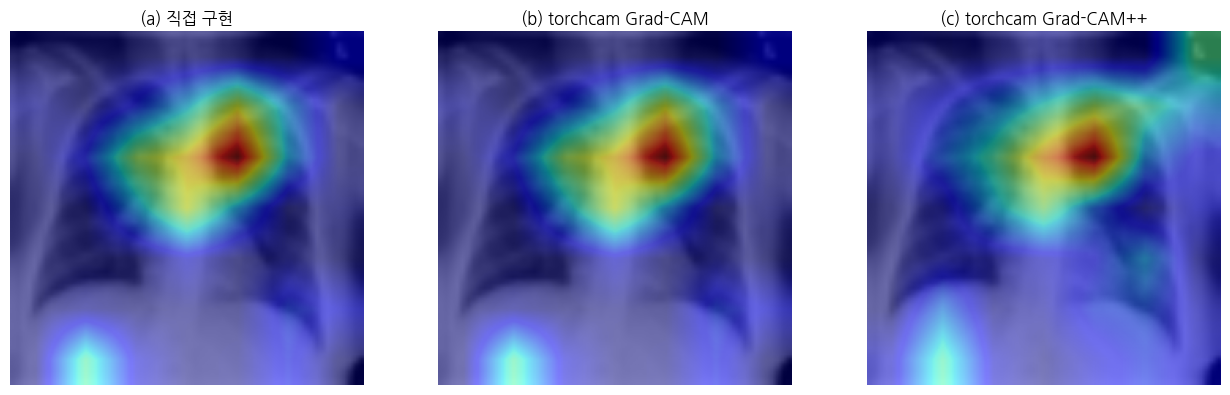

✅ 직접 구현과 torchcam Grad-CAM의 결과가 거의 동일해야 정상


In [33]:
# ============================================================
# 실습 2-1, 2-2, 2-3: torchcam으로 Grad-CAM / Grad-CAM++ 계산
# ============================================================
from torchcam.methods import GradCAM as TC_GradCAM, GradCAMpp as TC_GradCAMpp

# 같은 입력으로 비교 — 직접 구현 / torchcam GradCAM / torchcam GradCAM++
# (1) 직접 구현 — 위 실습 1에서 얻은 결과 재사용
gc_mine = GradCAM(model, model.layer4[-1])
cam_mine, pred_cls, _ = gc_mine(input_tensor, target_class=None)
cam_mine_up = F.interpolate(torch.from_numpy(cam_mine)[None, None], size=(224,224),
                            mode='bilinear', align_corners=False).squeeze().numpy()
gc_mine.remove_hooks()

# (2) torchcam GradCAM
# torchcam은 입력에 requires_grad가 필요하지 않고, model을 forward한 결과 logits을 직접 받음
tc_gc = TC_GradCAM(model, target_layer='layer4')
logits = model(input_tensor)
act_map = tc_gc(class_idx=int(pred_cls), scores=logits)[0]  # (H, W) tensor
cam_tc = act_map.squeeze().detach().cpu().numpy()
cam_tc_up = F.interpolate(torch.from_numpy(cam_tc)[None, None], size=(224,224),
                          mode='bilinear', align_corners=False).squeeze().numpy()
tc_gc.remove_hooks()

# (3) torchcam GradCAM++
tc_pp = TC_GradCAMpp(model, target_layer='layer4')
logits2 = model(input_tensor)
act_pp = tc_pp(class_idx=int(pred_cls), scores=logits2)[0]
cam_pp = act_pp.squeeze().detach().cpu().numpy()
cam_pp_up = F.interpolate(torch.from_numpy(cam_pp)[None, None], size=(224,224),
                          mode='bilinear', align_corners=False).squeeze().numpy()
tc_pp.remove_hooks()

# 3패널 시각화
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, cam_x, title in zip(axes,
                            [cam_mine_up, cam_tc_up, cam_pp_up],
                            ['(a) 직접 구현', '(b) torchcam Grad-CAM', '(c) torchcam Grad-CAM++']):
    ax.imshow(img_resized, cmap='gray'); ax.imshow(cam_x, cmap='jet', alpha=0.5)
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
print("✅ 직접 구현과 torchcam Grad-CAM의 결과가 거의 동일해야 정상")


### 💡 해석
- **(a)와 (b)** 가 거의 같다면 직접 구현이 올바르다는 검증 (구현 디버깅 기법)
- **(c) Grad-CAM++** 는 채널 가중치 계산이 다르므로 정밀 영역에서 더 선명해질 수 있음

> **핵심**: 실무에서는 검증된 라이브러리를, 학습/디버깅에서는 직접 구현을 병행.

---
## 🎯 실습 2-B — 강사 시연: 일괄 처리 + 정량 분석

> **수강생 실습은 Kaggle 환경에서 진행합니다.** 본 노트북에서는 강사가 두 가지 활용 패턴만 시연합니다.

| 시연 | 내용 | 산출물 |
|------|------|------|
| ① 일괄 처리 + PNG 저장 | N장에 Grad-CAM 적용 후 `outputs/gradcam/` 저장 | **M2 오분류 분석 입력** |
| ② Layer별 hotspot 정량 비교 | layer4/3/2 hotspot 픽셀 수 측정 | receptive field 가설 검증 |

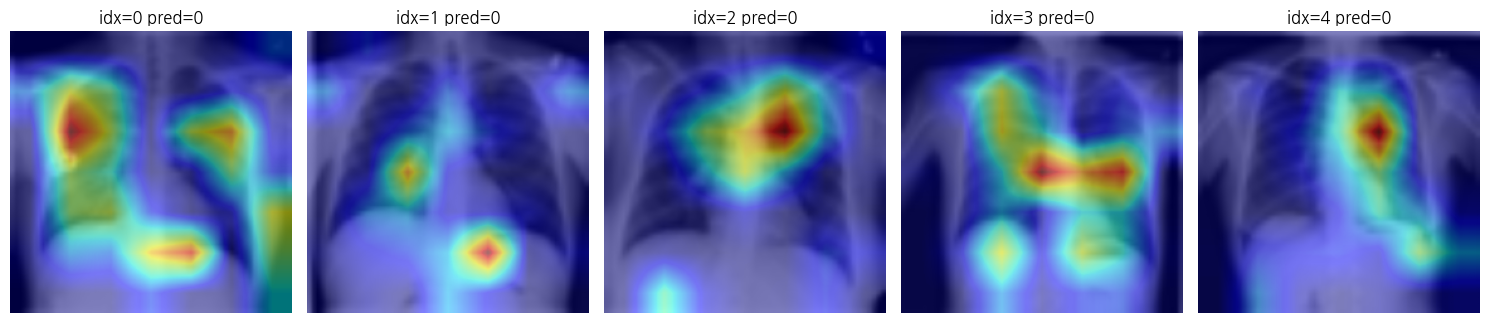

✅ 5장 Grad-CAM 시각화 완료


In [34]:
# ============================================================
# 🎬 강사 시연 ①: N장 일괄 Grad-CAM 시각화
# ============================================================
# N장 영상에 동일한 Grad-CAM 파이프라인을 적용해 한 번에 비교.

N_IMAGES = 5
batch_indices = list(range(N_IMAGES))

fig, axes = plt.subplots(1, N_IMAGES, figsize=(3*N_IMAGES, 4))
if N_IMAGES == 1: axes = [axes]
for i, idx in enumerate(batch_indices):
    t_i, img_i, _ = prep_input_from_idx(idx)
    gc = GradCAM(model, model.layer4[-1])
    cam_b, cls_b, _ = gc(t_i, target_class=None)
    cam_up = F.interpolate(torch.from_numpy(cam_b)[None, None], size=(224,224),
                            mode='bilinear', align_corners=False).squeeze().numpy()
    gc.remove_hooks()
    axes[i].imshow(img_i, cmap='gray'); axes[i].imshow(cam_up, cmap='jet', alpha=0.5)
    axes[i].set_title(f'idx={idx} pred={cls_b}'); axes[i].axis('off')
plt.tight_layout(); plt.show()
print(f"✅ {N_IMAGES}장 Grad-CAM 시각화 완료")

In [35]:
# ============================================================
# 🎬 강사 시연 ②: Layer별 hotspot 정량 비교
# ============================================================
# layer4 / layer3 / layer2 각각에서 Grad-CAM 생성 → threshold>0.5 픽셀 수 측정
# "깊은 layer일수록 hotspot이 의미 단위로 뭉친다"는 가설을 정량 확인

import pandas as pd
THRESHOLD = 0.5
demo_indices = [0, 5, 12]
layer_dict = {'layer2': model.layer2[-1], 'layer3': model.layer3[-1], 'layer4': model.layer4[-1]}
rows = []
for idx in demo_indices:
    t_i, _, _ = prep_input_from_idx(idx)
    row = {'image': f'idx_{idx}'}
    for lname, lmod in layer_dict.items():
        gc = GradCAM(model, lmod)
        cam_l, _, _ = gc(t_i, target_class=None)
        cam_up = F.interpolate(torch.from_numpy(cam_l)[None, None], size=(224, 224),
                                mode='bilinear', align_corners=False).squeeze().numpy()
        row[lname] = int((cam_up > THRESHOLD).sum())
        gc.remove_hooks()
    rows.append(row)
df = pd.DataFrame(rows)
print('Threshold > 0.5 픽셀 수 (hotspot 면적):')
print(df.to_string(index=False))
print()
print('🎓 강사 해설:')
print(' - layer2(28×28): receptive field 좁음 → 디테일에 산발적 반응 → hotspot 면적 큼')
print(' - layer3(14×14): 균형')
print(' - layer4(7×7) : 의미 단위로 응축 → 임상 ROI(bbox)와 비교 가능 (M2 Pointing Game)')

  ⚠️ Grad-CAM: ReLU 후 신호가 0 → |pre-ReLU|로 fallback (이 layer의 모든 채널 가중치가 음의 기여를 했음)
Threshold > 0.5 픽셀 수 (hotspot 면적):
 image  layer2  layer3  layer4
 idx_0   29219     324    7108
 idx_5    4051     395    4766
idx_12    5657     598    6962

🎓 강사 해설:
 - layer2(28×28): receptive field 좁음 → 디테일에 산발적 반응 → hotspot 면적 큼
 - layer3(14×14): 균형
 - layer4(7×7) : 의미 단위로 응축 → 임상 ROI(bbox)와 비교 가능 (M2 Pointing Game)


---
# 📋 정리 & 핵심 요약

## 스스로 점검해보기
1. ❓ Grad-CAM의 핵심 한 줄 정의는? (feature map과 class gradient의 ___?)
2. ❓ PyTorch hook이 필요한 이유는? (`forward`와 `backward`에서 각각 무엇을 캐처?)
3. ❓ target_class가 바뀌면 heatmap이 왜 달라지는가? (Grad-CAM 공식 어느 항이 바뀌나?)

## 핵심 코드 한 줄 요약
| 개념 | 코드 |
|------|------|
| Forward hook | `layer.register_forward_hook(fn)` |
| Backward hook | `layer.register_full_backward_hook(fn)` |
| 타겟 score backward | `logits[:, c].sum().backward()` |
| 채널별 gradient 평균 | `grad.mean(dim=(2,3), keepdim=True)` |
| 가중합 + ReLU | `F.relu((α * features).sum(dim=1))` |
| torchcam 사용 | `from torchcam.methods import GradCAM` |

## 다음 시간 예고
> **M2. 오분류 사례 분석 & XAI 신뢰성** — Grad-CAM이라는 도구를 손에 쥐었다. 이제 오분류·shortcut·sanity check로 saliency 자체를 검증한다.